# BAN7201 Lecture Notebook  
## Dissecting Visual Models with the Superstore Dataset

**Course:** BAN7201 Data Visualization  
**Topic:** Dissecting Visual Models  
**Focus:** Gestalt Principles, Preattentive Attributes, and Business Insight

---

## Lecture Purpose

In this lecture, we will examine how the same dataset can produce either a weak visualization or a strong one depending on design choices.  
The goal is not only to create charts, but to **dissect visual models** by asking:

1. What business question is the visual trying to answer?  
2. What variables are being encoded?  
3. Which visual encodings are used?  
4. Does the chart support quick and accurate interpretation?  
5. How can Gestalt principles and preattentive attributes improve the chart?

---

## Learning Objectives

By the end of this lecture, students should be able to:

- identify the components of a visual model  
- critique weak visualizations  
- apply Gestalt principles to improve structure and grouping  
- apply preattentive attributes to guide attention  
- redesign a chart so that business insight becomes easier to interpret


## Dataset

This notebook uses the **Superstore** dataset, which is widely used in business analytics and visualization practice.

**Expected file name:** `Sample - Superstore.csv`

Place the CSV file in the same folder as this notebook, or update the path in the next code cell.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_PATH = "../../data/Superstore.csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")

if "Order Date" in df.columns:
    df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Part 1. What Is a Visual Model?

A **visual model** is a structured representation of data using visual encodings such as:

- **position**
- **length**
- **color**
- **size**
- **shape**
- **orientation**

Present data in a graphical or visual format to allow for quick and
effective interpretation of data, leading to better decision-making
and insights.

To dissect a visual model, we can ask:

### Layer 1: Data Layer
What variables are in the data?

### Layer 2: Encoding Layer
How are those variables mapped to visual elements?

### Layer 3: Perception Layer
How do viewers interpret the chart quickly, or struggle with it?

In business settings, a strong visual model should reduce cognitive effort and increase decision-making clarity.


# Example 1: Profit by Sub-Category

## Business Question
Which product sub-categories are hurting profitability?

We will first create a **bad chart** and then redesign it into a **good chart**.


In [2]:
subcat_profit = (
    df.groupby("Sub-Category", as_index=False)["Profit"]
      .sum()
)

subcat_profit.head()


,Sub-Category,Profit
0,Accessories,41936.6357
1,Appliances,18138.0054
2,Art,6527.7870
3,Binders,30221.7633
4,Bookcases,-3472.5560


## Bad Visualization 1

This chart is intentionally poor. It is not wrong in the data sense, but it is weak in the design sense.

### Problems to Notice
- categories are not sorted
- colors are random and do not encode meaning
- the key message is not emphasized
- the viewer must work too hard to find the loss-making sub-categories


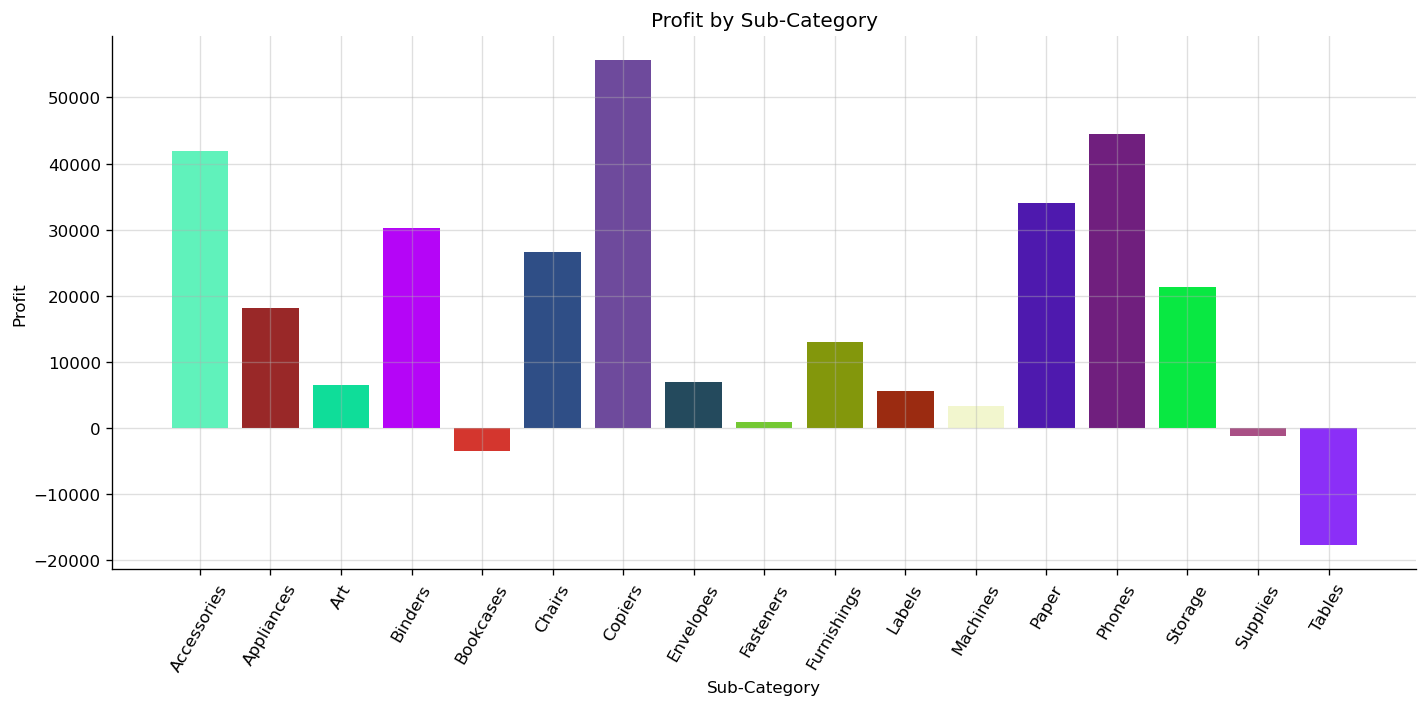

In [3]:
np.random.seed(42)
random_colors = np.random.rand(len(subcat_profit), 3)

plt.figure(figsize=(12, 6))
plt.bar(subcat_profit["Sub-Category"], subcat_profit["Profit"], color=random_colors)
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=60)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Dissecting the Bad Visualization

### What is the chart trying to answer?
It tries to show profit performance across sub-categories.

### What is wrong with the visual model?
- **Position is underused** because categories are not sorted.
- **Color is misused** because random color creates noise rather than meaning.
- **Figure-ground is weak** because nothing important stands out.
- **Similarity is violated** because similar items do not share a consistent visual treatment.
- **Continuity is weak** because the eye does not move through the categories in a meaningful order.

This chart is technically valid, but not decision-friendly.


## Good Visualization 1

Now we improve the visual using:

### Gestalt Principles
- **Similarity:** use one neutral color for normal items
- **Figure-Ground:** highlight problem areas so they stand out
- **Continuity:** sort bars to guide the eye naturally

### Preattentive Attributes
- **Position / Length:** strongest encoding for comparison
- **Color:** highlight loss-making sub-categories


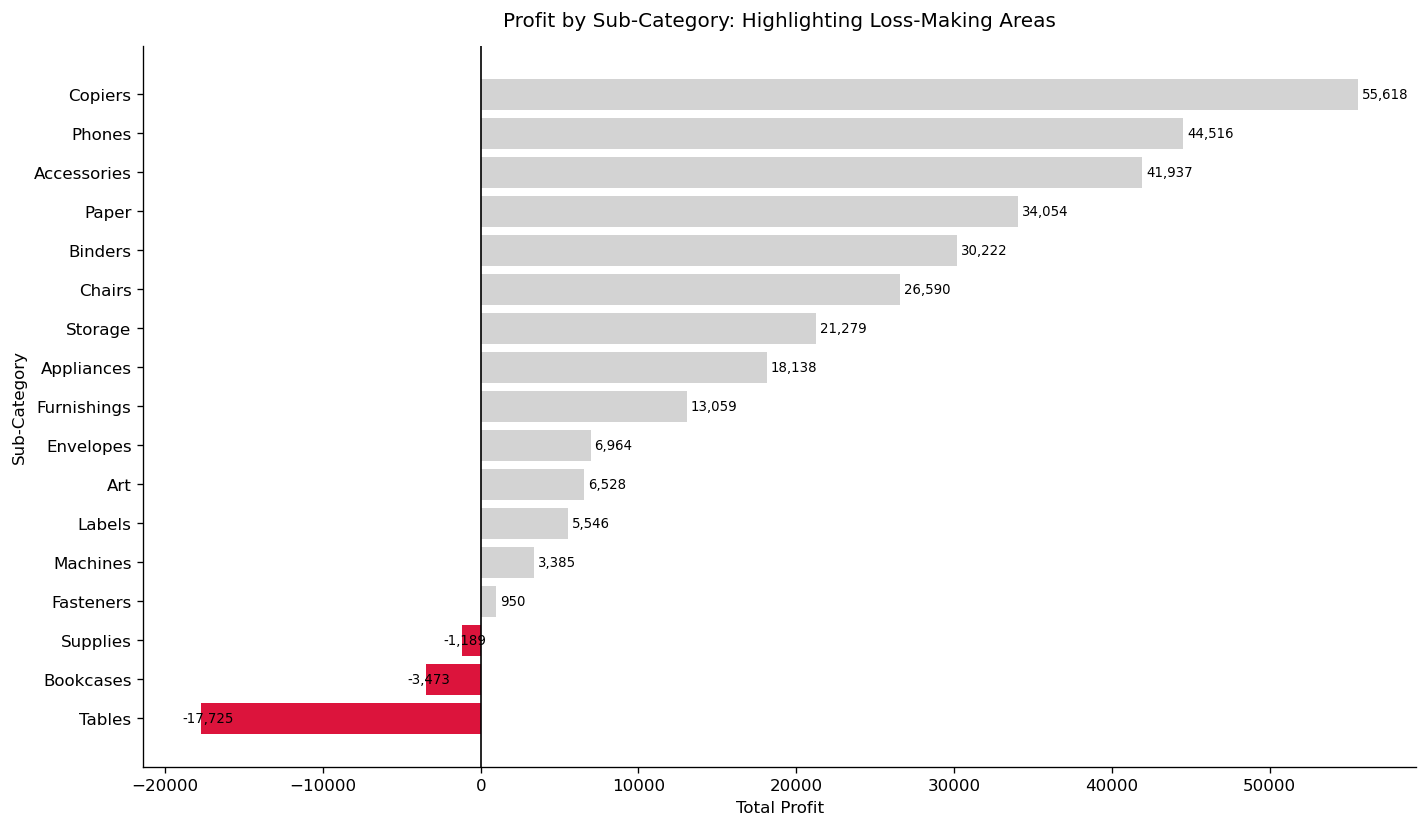

In [4]:
subcat_profit_sorted = subcat_profit.sort_values("Profit")

colors = ["crimson" if p < 0 else "lightgray" for p in subcat_profit_sorted["Profit"]]

plt.figure(figsize=(12, 7))
bars = plt.barh(subcat_profit_sorted["Sub-Category"], subcat_profit_sorted["Profit"], color=colors)

plt.axvline(0, color="black", linewidth=1)
plt.title("Profit by Sub-Category: Highlighting Loss-Making Areas", pad=12)
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    offset = 250 if width >= 0 else -1200
    plt.text(width + offset, y, f"{width:,.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()


## Why the Improved Version Works

### Business Insight
A manager can quickly identify which sub-categories are generating losses and may require pricing, discount, sourcing, or inventory review.

### Why the design is stronger
- Sorted bars improve ranking and comparison.
- Losses stand out immediately through color.
- Neutral gray reduces unnecessary attention on noncritical categories.
- The horizontal format improves readability for long labels.
- The zero reference line clarifies positive vs negative performance.


# Example 2: Sales vs Profit by Segment

## Business Question
How do customer segments differ in terms of sales and profit?

This example is useful for discussing **size**, which is often misused in dashboards and student work.


## Bad Visualization 2

In this version, the chart uses:
- random colors with no meaning
- **double encoding** of Sales on both the x-axis and bubble size
- no clear grouping by segment
- visual clutter that does not help the viewer answer the question


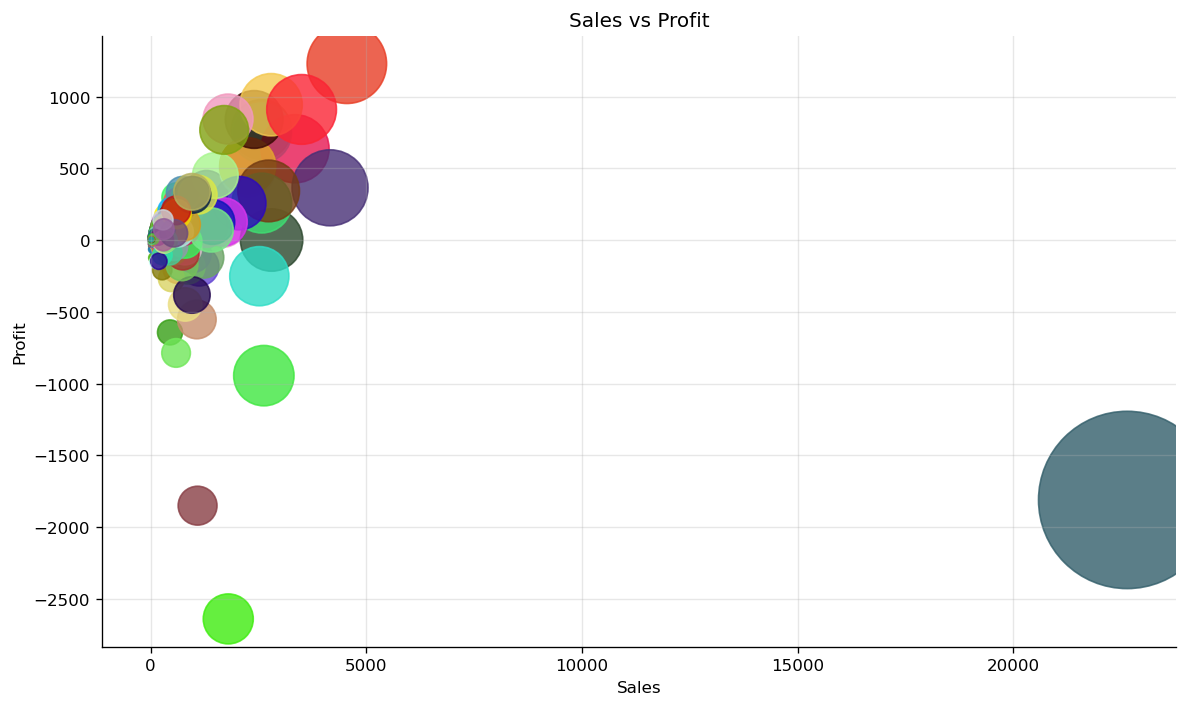

In [5]:
sample = df.sample(min(800, len(df)), random_state=42).copy()

np.random.seed(42)
bad_colors = np.random.rand(len(sample), 3)

plt.figure(figsize=(10, 6))
plt.scatter(
    sample["Sales"],
    sample["Profit"],
    s=sample["Sales"] / 2,
    c=bad_colors,
    alpha=0.8
)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Dissecting the Bad Scatterplot

### What is wrong?
- **Sales** is encoded twice: on the x-axis and in size.
- Random color adds visual noise.
- No consistent grouping is provided for customer segment.
- Large values dominate attention whether they are meaningful or not.

### Teaching Point
A chart can contain more encoding, but that does **not** mean it communicates better.


## Good Visualization 2

We improve the chart by aggregating at the **segment** level.

### Encodings
- **X-axis:** total Sales  
- **Y-axis:** total Profit  
- **Size:** total Quantity  
- **Shape:** Segment  

### Why this is better
Each encoding now represents a different variable.  
The chart becomes easier to interpret and more aligned with the business question.


In [6]:
segment_perf = (
    df.groupby("Segment", as_index=False)
      .agg({
          "Sales": "sum",
          "Profit": "sum",
          "Quantity": "sum"
      })
)

segment_perf


,Segment,Sales,Profit,Quantity
0,Consumer,1.161401e+06,134119.2092,19521
1,Corporate,7.061464e+05,91979.1340,11608
2,Home Office,4.296531e+05,60298.6785,6744


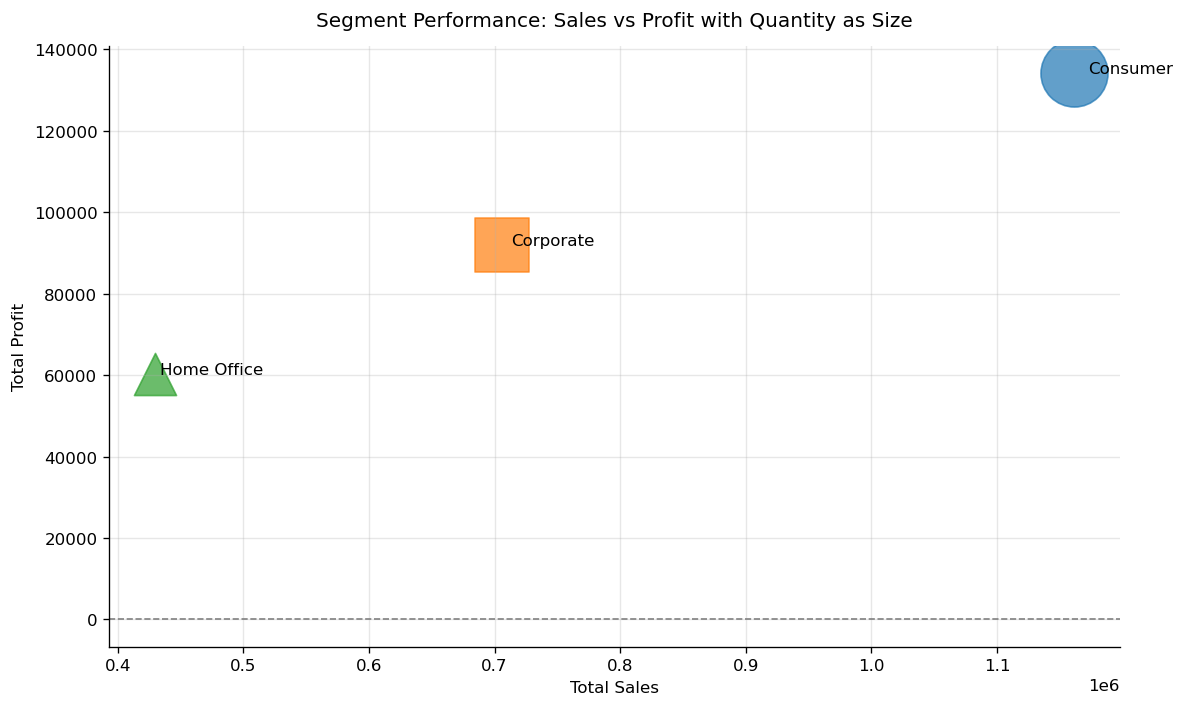

In [7]:
marker_map = {
    "Consumer": "o",
    "Corporate": "s",
    "Home Office": "^"
}

fig, ax = plt.subplots(figsize=(10, 6))

sizes = (segment_perf["Quantity"] / segment_perf["Quantity"].max()) * 1500 + 120

for i, row in segment_perf.iterrows():
    ax.scatter(
        row["Sales"],
        row["Profit"],
        s=sizes.iloc[i],
        marker=marker_map.get(row["Segment"], "o"),
        alpha=0.7,
        label=row["Segment"]
    )
    ax.text(row["Sales"] * 1.01, row["Profit"], row["Segment"], fontsize=10)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Segment Performance: Sales vs Profit with Quantity as Size", pad=12)
ax.set_xlabel("Total Sales")
ax.set_ylabel("Total Profit")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Why the Improved Segment Chart Works

### Gestalt Principles
- **Similarity:** each segment keeps a consistent marker shape
- **Proximity:** labels are placed close to points
- **Figure-Ground:** reduced clutter makes the message clearer

### Preattentive Attributes
- **Position:** most accurate comparison of Sales and Profit
- **Size:** represents Quantity, which adds new information
- **Shape:** distinguishes segment categories

### Business Insight
Students can compare whether high-sales segments also produce high profit and whether higher order volume aligns with profitability.


# Example 3: Discount and Profit Margin

## Business Question
Does heavier discounting appear to reduce profitability?

This example is useful for **orientation**, **continuity**, and trend interpretation.


In [8]:
margin_df = df.copy()
margin_df = margin_df[margin_df["Sales"] > 0].copy()
margin_df["Profit Margin"] = margin_df["Profit"] / margin_df["Sales"]
margin_df = margin_df[(margin_df["Profit Margin"] > -2) & (margin_df["Profit Margin"] < 1.5)]

margin_df[["Discount", "Profit Margin"]].head()


,Discount,Profit Margin
0,0.00,0.1600
1,0.00,0.3000
2,0.00,0.4700
3,0.45,-0.4000
4,0.20,0.1125


## Bad Visualization 3

This chart is intentionally weak because:
- random color adds noise
- extreme overplotting hides structure
- there is no summary trend
- the viewer must guess whether a pattern exists


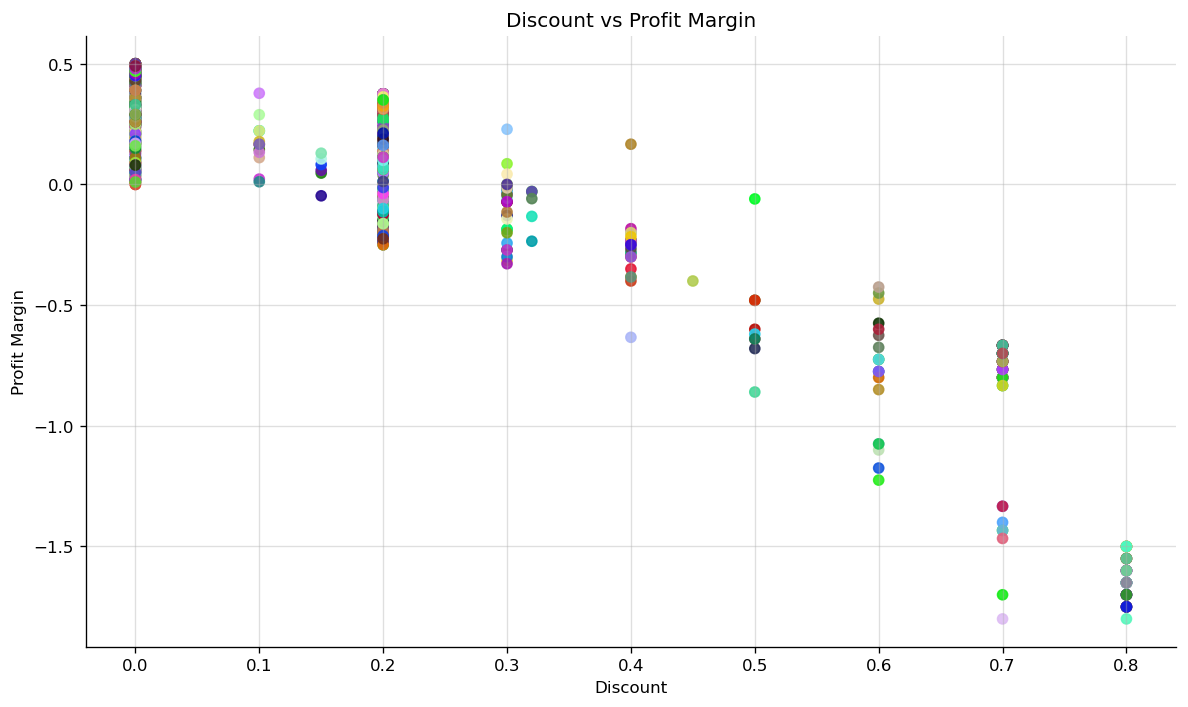

In [9]:
bad_sample = margin_df.sample(min(1500, len(margin_df)), random_state=42).copy()
np.random.seed(7)
bad_colors = np.random.rand(len(bad_sample), 3)

plt.figure(figsize=(10, 6))
plt.scatter(
    bad_sample["Discount"],
    bad_sample["Profit Margin"],
    c=bad_colors,
    alpha=0.9
)
plt.title("Discount vs Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Good Visualization 3

Now we improve the design by:
- reducing visual noise
- using a single muted point treatment
- adding a trend line
- using a clean layout to support pattern reading

### Why this matters
The goal is not to decorate the scatterplot.  
The goal is to help the viewer determine whether discounting is associated with lower profit margin.


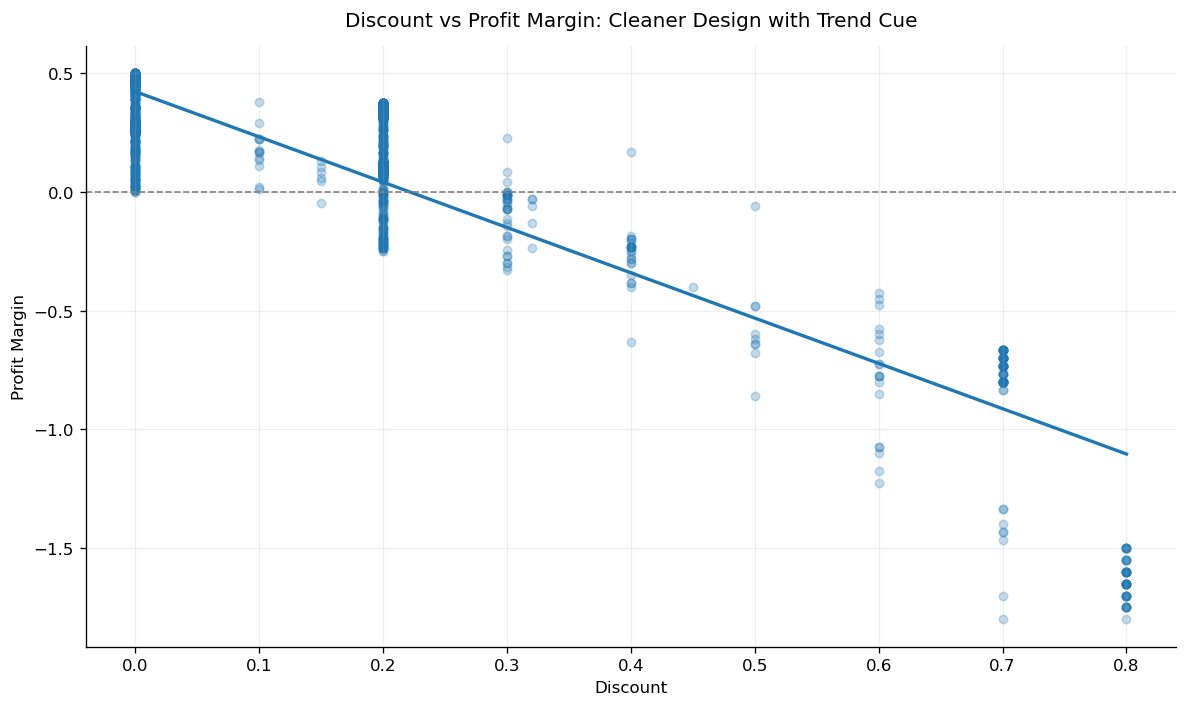

In [10]:
good_sample = margin_df.sample(min(1500, len(margin_df)), random_state=42).copy()

x = good_sample["Discount"].values
y = good_sample["Profit Margin"].values
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(10, 6))
plt.scatter(
    good_sample["Discount"],
    good_sample["Profit Margin"],
    alpha=0.25,
    s=25
)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, trend(x_line), linewidth=2)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Discount vs Profit Margin: Cleaner Design with Trend Cue", pad=12)
plt.xlabel("Discount")
plt.ylabel("Profit Margin")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Why the Improved Discount Chart Works

### Gestalt Principles
- **Continuity:** the trend line guides the eye across the pattern
- **Figure-Ground:** reduced clutter helps the main pattern stand out

### Preattentive Attributes
- **Position:** reveals the relationship between discount and profit margin
- **Orientation:** line direction provides an immediate cue about trend direction

### Business Insight
Higher discounts may be associated with weaker profit margin, suggesting that discount policy should be reviewed carefully.


# Summary Table: From Bad Visual to Better Visual

| Example | Weak Design Choice | Improved Design Choice | Main Insight |
|---|---|---|---|
| Profit by Sub-Category | random colors, unsorted bars | sorted bars, highlighted losses | identify unprofitable sub-categories |
| Sales vs Profit by Segment | double encoding, random color | meaningful size and shape | compare segment performance clearly |
| Discount vs Profit Margin | clutter, no trend cue | cleaner points and trend line | detect possible negative relationship |


# In-Class Discussion Prompts

1. What is the business question behind each chart?  
2. What visual encodings are being used?  
3. Which design choices increase cognitive load?  
4. Which Gestalt principles are being applied in the improved chart?  
5. Which preattentive attributes are most helpful in each example?  
6. Did the data change, or did only the design change?


# Mini Activity for Students

Choose one of the improved charts and answer:

1. What makes the original version weak?
2. Which perceptual principles were violated?
3. Which changes improved interpretation?
4. What business decision is now easier to make?

Students can also create their own **bad** chart first and then redesign it.


# Key Takeaways

- A chart can be technically correct but still visually weak.  
- Visualizations should reduce effort and increase insight.  
- Gestalt principles help structure what belongs together.  
- Preattentive attributes guide attention before conscious analysis begins.  
- Good data visualization is not decoration. It is decision support.
